## Задание №1

In [16]:
Tz_test = [0, 0.12, 1.291, 6.594, 6.821, 9.031, 14.971, 17.15]
Ts_test = [0, 0.634, 2.31, 6.78, 0.477, 5.104, 0.459, 1.442]
Tmod = 17

In [17]:
processed_programs = 4
rejections = 2
total_programs = 6
processing_probability = 0.667
cpu_time = 10.201
idle_time = 5.127
total_time = 17.15
cpu_utilization = 0.594
idle_probability = 0.299

print(f'Число обработанных программ: {processed_programs}')
print(f'Число отказов: {rejections}')
print(f'Общее число поступивших программ: {total_programs}')
print(f'Вероятность обработки: {processing_probability}')
print(f'Время работы процессора: {cpu_time} с')
print(f'Время простоя (между обслуживаниями): {idle_time} с')
print(f'Общее время моделирования: {total_time} с')
print(f'Загрузка процессора: {cpu_utilization}')
print(f'Вероятность простоя: {idle_probability}')


Число обработанных программ: 4
Число отказов: 2
Общее число поступивших программ: 6
Вероятность обработки: 0.667
Время работы процессора: 10.201 с
Время простоя (между обслуживаниями): 5.127 с
Общее время моделирования: 17.15 с
Загрузка процессора: 0.594
Вероятность простоя: 0.299


## Задание №2

In [18]:
import numpy as np

def model(Tz, Ts, Tmod):
    """
    Tz — моменты поступления заявок
    Ts — времена обслуживания
    Tmod — время моделирования
    """

    busy_until = 0          # момент освобождения процессора
    processed = 0
    refused = 0

    busy_time = 0
    idle_time = 0

    last_event_time = 0

    for i in range(1, len(Tz)):
        arrival = Tz[i]
        service = Ts[i]

        if arrival > Tmod:
            break

        # если процессор свободен
        if arrival >= busy_until:
            # добавляем простой
            idle_time += arrival - max(last_event_time, busy_until)

            start = arrival
            end = start + service

            busy_time += service
            busy_until = end

            processed += 1
            last_event_time = end

        else:
            refused += 1

    total_arrived = processed + refused
    total_time = max(busy_until, Tz[-1])

    relative_throughput = processed / total_arrived if total_arrived > 0 else 0
    cpu_load = busy_time / total_time if total_time > 0 else 0
    cpu_idle_prob = idle_time / total_time if total_time > 0 else 0

    return (
        processed,
        refused,
        total_arrived,
        round(relative_throughput, 3),
        round(busy_time, 3),
        round(idle_time, 3),
        round(total_time, 3),
        round(cpu_load, 3),
        round(cpu_idle_prob, 3)
    )

## Задание №3

In [19]:
Tz_test = [0, 0.12, 1.291, 6.594, 6.821, 9.031, 14.971, 17.15]
Ts_test = [0, 0.634, 2.31, 6.78, 0.477, 5.104, 0.459, 1.442]
Tmod = 17

result = model(Tz_test, Ts_test, Tmod)

result

(4, 2, 6, 0.667, 10.183, 5.247, 17.15, 0.594, 0.306)

In [20]:
print(f'Число обработанных программ: {result[0]}')
print(f'Число отказов: {result[1]}')
print(f'Общее число поступивших программ: {result[2]}')
print(f'Вероятность обработки: {result[3]}')
print(f'Время работы процессора: {result[4]} с')
print(f'Время простоя (между обслуживаниями): {result[5]} с')
print(f'Общее время моделирования: {result[6]} с')
print(f'Загрузка процессора: {result[7]}')
print(f'Вероятность простоя: {result[8]}')


Число обработанных программ: 4
Число отказов: 2
Общее число поступивших программ: 6
Вероятность обработки: 0.667
Время работы процессора: 10.183 с
Время простоя (между обслуживаниями): 5.247 с
Общее время моделирования: 17.15 с
Загрузка процессора: 0.594
Вероятность простоя: 0.306


In [21]:
print('=' * 140)
print('СРАВНЕНИЕ РЕЗУЛЬТАТОВ ЗАДАНИЯ 1 И ЗАДАНИЯ 2')
print('=' * 140)
print()

print(f'{"Параметр":<40} {"Задание 1":<15} {"Задание 2":<15} {"Разница":<10}')
print('-' * 140)
print(f'{"Число обработанных программ":<40} {processed_programs:<15} {result[0]:<15} {result[0] - processed_programs:<10}')
print(f'{"Число отказов":<40} {rejections:<15} {result[1]:<15} {result[1] - rejections:<10}')
print(f'{"Общее число поступивших программ":<40} {total_programs:<15} {result[2]:<15} {result[2] - total_programs:<10}')
print(f'{"Вероятность обработки":<40} {processing_probability:<15} {result[3]:<15} {result[3] - processing_probability:<10}')
print(f'{"Время работы процессора (с)":<40} {cpu_time:<15} {result[4]:<15} {result[4] - cpu_time:<10}')
print(f'{"Время простоя (с)":<40} {idle_time:<15} {result[5]:<15} {result[5] - idle_time:<10}')
print(f'{"Общее время моделирования (с)":<40} {total_time:<15} {result[6]:<15} {result[6] - total_time:<10}')
print(f'{"Загрузка процессора":<40} {cpu_utilization:<15} {result[7]:<15} {result[7] - cpu_utilization:<10}')
print(f'{"Вероятность простоя":<40} {idle_probability:<15} {result[8]:<15} {result[8] - idle_probability:<10}')
print('=' * 140)

СРАВНЕНИЕ РЕЗУЛЬТАТОВ ЗАДАНИЯ 1 И ЗАДАНИЯ 2

Параметр                                 Задание 1       Задание 2       Разница   
--------------------------------------------------------------------------------------------------------------------------------------------
Число обработанных программ              4               4               0         
Число отказов                            2               2               0         
Общее число поступивших программ         6               6               0         
Вероятность обработки                    0.667           0.667           0.0       
Время работы процессора (с)              10.201          10.183          -0.018000000000000682
Время простоя (с)                        5.127           5.247           0.1200000000000001
Общее время моделирования (с)            17.15           17.15           0.0       
Загрузка процессора                      0.594           0.594           0.0       
Вероятность простоя                    

## Задание №4

In [22]:
def generate_stream(lmbda, mu, Tmod):
    Tz = [0]
    Ts = [0]

    current_time = 0

    while current_time < Tmod:
        interarrival = np.random.exponential(1/lmbda)
        current_time += interarrival
        Tz.append(current_time)

        service_time = np.random.exponential(1/mu)
        Ts.append(service_time)

    return Tz, Ts

In [23]:
def run_experiment(lmbda, mu, Tmod=10000):
    Tz, Ts = generate_stream(lmbda, mu, Tmod)
    res = model(Tz, Ts, Tmod)

    Q_sim = res[3]      # относительная пропускная способность
    load_sim = res[7]   # загрузка процессора

    return Q_sim, load_sim

In [24]:
import matplotlib.pyplot as plt

mu = 1
rho_values = np.linspace(0.01, 1, 20)

Q_sim_list = []
load_sim_list = []
Q_theory = []
load_theory = []

for rho in rho_values:
    lmbda = rho * mu

    Q_sim, load_sim = run_experiment(lmbda, mu)

    Q_sim_list.append(Q_sim)
    load_sim_list.append(load_sim)

    Q_theory.append(1/(1+rho))
    load_theory.append(rho/(1+rho))

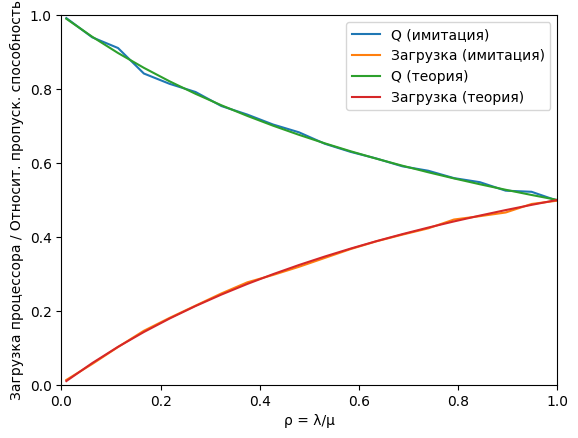

In [26]:
plt.figure()
plt.plot(rho_values, Q_sim_list, label='Q (имитация)')
plt.plot(rho_values, load_sim_list, label='Загрузка (имитация)')
plt.plot(rho_values, Q_theory, label='Q (теория)')
plt.plot(rho_values, load_theory, label='Загрузка (теория)')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("ρ = λ/μ")
plt.ylabel("Загрузка процессора / Относит. пропуск. способность")
plt.legend()
plt.show()
